In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from thermosim.utils.io import load_irb_txt


In [36]:
arr, settings, params = load_irb_txt("../data/Wölbungskorrektur Messung 3/Untersuchung Fisch 3_0002.csv")
print("Data shape:", arr.shape)
print("Settings:", settings)
print("Params:", params)

Data shape: (480, 640)
Settings: {'Version': 3, 'ImageWidth': 640, 'ImageHeight': 480, 'ShotRange': [22.41, 28.72], 'CalibRange': [-40.15, 119.85], 'TempUnit': '°C'}
Params: {'Filename': 'Untersuchung Fisch 3_0002.irb', 'FrameIndex': 2, 'RecDate': '16.12.2025', 'RecTime': '13:10:25', 'ms': 9999.47}


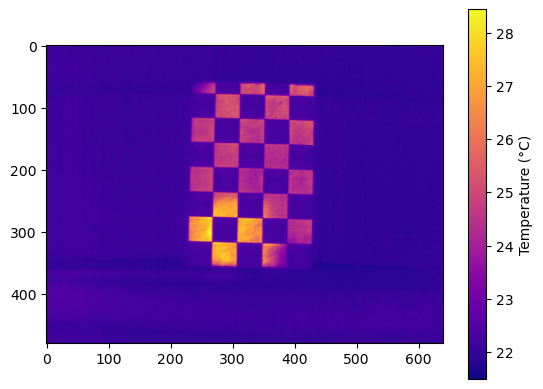

In [37]:
plt.imshow(arr, cmap="plasma")
plt.colorbar(label="Temperature (°C)")

## Pre-Processing
- Gradient correction
- edge and checkerboard detection for cropping


In [38]:
def edges_from_float(T, p=(2, 98), blur_sigma=1.0,
                     canny_low=3, canny_high=150):
    """
    T : 2D float image (thermogram)
    returns: uint8 image, edges (uint8 0/255)
    """

    T = np.asarray(T, dtype=np.float32)

    # 1) Robust normalization (ignore outliers)
    lo, hi = np.percentile(T[np.isfinite(T)], p)
    Tn = np.clip((T - lo) / (hi - lo + 1e-12), 0, 1)

    # 2) Convert to uint8 for OpenCV
    img_u8 = (255 * Tn).astype(np.uint8)

    # 3) Small blur (stabilizes Canny on thermal noise)
    if blur_sigma > 0:
        img_u8 = cv2.GaussianBlur(img_u8, (0, 0), blur_sigma)

    # 4) Edge detection
    edges = cv2.Canny(img_u8, canny_low, canny_high, L2gradient=True)

    return img_u8, edges

def crop_to_edges(img, edges, pad=0):
    """
    img   : 2D or 3D image to crop (e.g. uint8 preview or the original float T)
    edges : uint8 edge map (0/255)
    pad   : extra pixels around the tight box
    returns: cropped_img, (x, y, w, h)
    """
    pts = cv2.findNonZero(edges)  # Nx1x2, or None
    if pts is None:
        # No edges found
        return img, (0, 0, img.shape[1], img.shape[0])

    x, y, w, h = cv2.boundingRect(pts)

    # Apply padding and clip to image bounds
    H, W = edges.shape[:2]
    x0 = max(0, x - pad)
    y0 = max(0, y - pad)
    x1 = min(W, x + w + pad)
    y1 = min(H, y + h + pad)

    cropped = img[y0:y1, x0:x1]
    return cropped, (x0, y0, x1 - x0, y1 - y0)

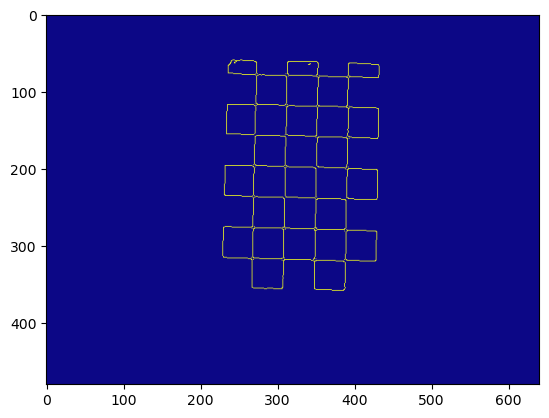

In [39]:
img_u8, edges = edges_from_float(arr)

cropped, (x0, y0, w, h) = crop_to_edges(img_u8,edges)


plt.imshow(edges,cmap="plasma")


In [40]:
# Estimate background (large blur kernel)
bg = cv2.GaussianBlur(cropped, (101, 101), 0)

# Flat-field correction
corrected = cropped / (bg + 1e-6)
corrected = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)

corrected = corrected.astype(np.uint8)

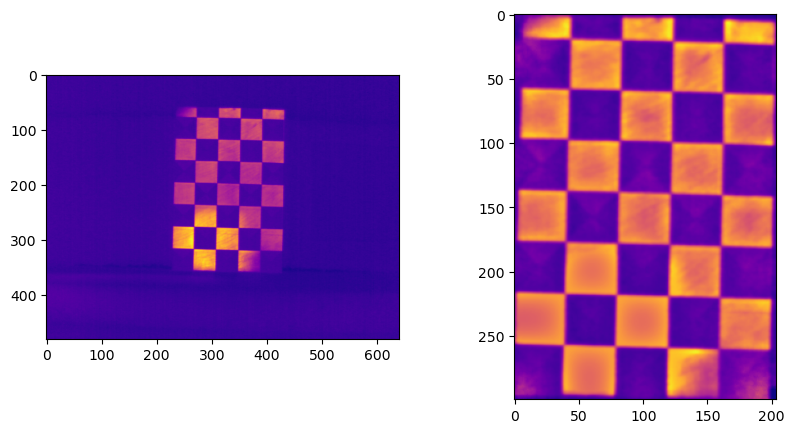

In [41]:
fig, axs = plt.subplots(1,2,figsize=(10,5))


axs[0].imshow(arr,cmap="plasma")
axs[1].imshow(corrected,cmap="plasma")

In [42]:
def to_u8(img):
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return (img * 255).astype(np.uint8)


def detect_corners_binary(img, pattern_size):
    # bw = thermal_to_binary(img, method="otsu")

    flags = cv2.CALIB_CB_EXHAUSTIVE | cv2.CALIB_CB_ACCURACY
    ok, corners = cv2.findChessboardCornersSB(img, pattern_size, flags)

    if not ok:
        # try inverted binary
        bw_inv = cv2.bitwise_not(img)
        ok, corners = cv2.findChessboardCornersSB(bw_inv, pattern_size, flags)

    return corners if ok else None, img

def bounding_box_from_binary(bin_img):
    """
    bin_img: 2D numpy array with values {0,1} or {0,255}
    returns: (x_min, y_min, x_max, y_max)
    """

    bin_img = bin_img.astype(bool)

    if not bin_img.any():
        raise ValueError("Binary image contains no foreground pixels")

    ys, xs = np.where(bin_img)
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    return x_min, y_min, x_max + 1, y_max + 1

In [43]:
def thermal_to_binary(img, method="adaptive"):
    """
    img : numpy array (float or int thermal image)
    returns: binary uint8 image (0 or 255)
    """

    # --- normalize robustly ---
    x = img.astype(np.float32)
    lo, hi = np.percentile(x, (2, 98))
    x = np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)
    u8 = (255 * x).astype(np.uint8)

    # --- denoise (important for thermal) ---
    u8 = cv2.GaussianBlur(u8, (5, 5), 0)

    # --- threshold ---
    if method == "otsu":
        _, bw = cv2.threshold(
            u8, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
    elif method == "adaptive":
        bw = cv2.adaptiveThreshold(
            u8, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            blockSize=31,  # odd, tune if needed
            C=2
        )
    else:
        raise ValueError("method must be 'otsu' or 'adaptive'")

    # # --- morphology: clean checkerboard edges ---
    # kernel = np.ones((3,3), np.uint8)
    # bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel)
    # bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel)

    return bw

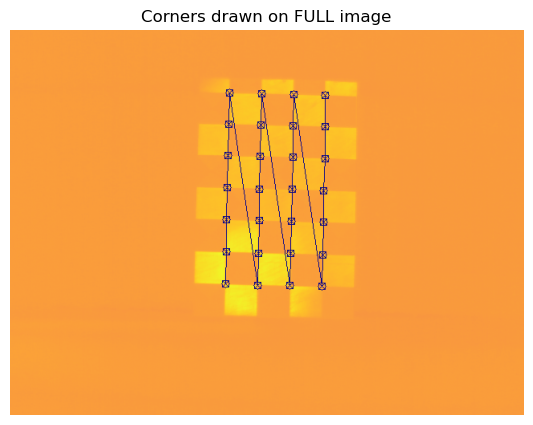

In [44]:
_, binary = cv2.threshold(
    corrected, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)



corners, _ = detect_corners_binary(binary, pattern_size=(7, 4))

if corners is not None:
    # corners is (N,1,2). Add offsets to x,y
    corners_full = corners.copy()
    corners_full[:, 0, 0] += x0  # x
    corners_full[:, 0, 1] += y0  # y

    cv2.drawChessboardCorners(
        arr,
        patternSize=(7, 4),
        corners=corners_full,
        patternWasFound=True
    )

plt.figure(figsize=(7, 5))
plt.imshow(arr, cmap="plasma")
plt.axis("off")
plt.title("Corners drawn on FULL image")
plt.show()

## rest

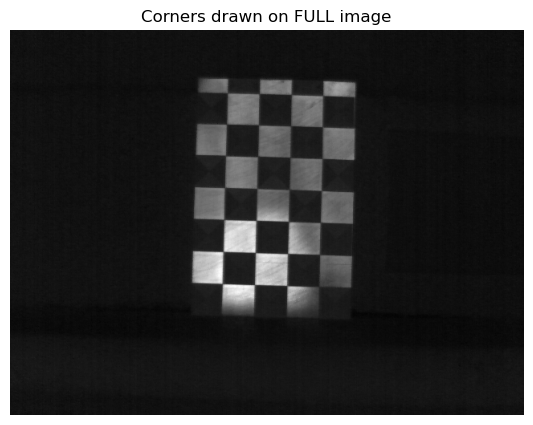

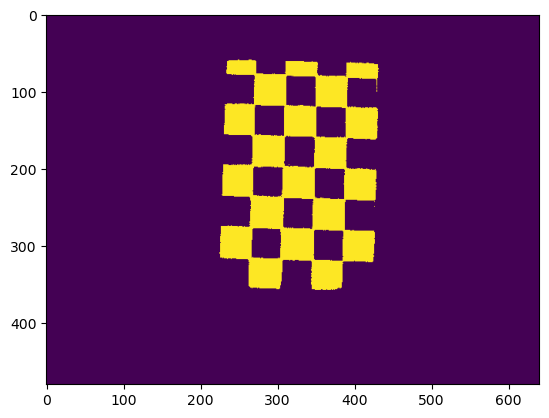

In [69]:
# bin_img = thermal_to_binary(arr, method="otsu")  # 0/255 (or 0/1 depending on your function)
bin_img = np.array(arr > 22.5).astype(np.uint8)

x0, y0, x1, y1 = bounding_box_from_binary(bin_img)

cropped = bin_img[y0:y1-40, x0:x1]

# detect on cropped
corners, _ = detect_corners_binary(cropped, pattern_size=(6, 4))

# prepare full image for drawing (use binary or to_u8(arr); binary is easiest here)

vis_full = cv2.cvtColor(to_u8(arr), cv2.COLOR_GRAY2BGR)

if corners is not None:
    # corners is (N,1,2). Add offsets to x,y
    corners_full = corners.copy()
    corners_full[:, 0, 0] += x0  # x
    corners_full[:, 0, 1] += y0  # y

    cv2.drawChessboardCorners(
        vis_full,
        patternSize=(7, 4),
        corners=corners_full,
        patternWasFound=True
    )

plt.figure(figsize=(7, 5))
plt.imshow(vis_full, cmap="gray")
plt.axis("off")
plt.title("Corners drawn on FULL image")
plt.show()

plt.imshow(bin_img)

In [66]:
def make_objp(pattern_size, square_size):
    nx, ny = pattern_size
    objp = np.zeros((nx*ny, 3), np.float32)
    objp[:, :2] = np.mgrid[0:nx, 0:ny].T.reshape(-1, 2)
    objp *= square_size
    return objp


def calibrate_standard_single_view(objp, corners_full, imshape_wh):
    # objp: (N,3) float32
    # corners_full: (N,1,2) or (N,2) float32
    objp = np.asarray(objp, np.float32).reshape(-1, 3)
    imgp = np.asarray(corners_full, np.float32).reshape(-1, 1, 2)

    objpoints = [objp]
    imgpoints = [imgp]

    rms, K, dist, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, imshape_wh, None, None
    )
    return rms, K, dist, rvecs, tvecs


In [67]:
objp  = make_objp(pattern_size=(7, 4),square_size=1)

In [68]:
h, w = arr_.shape[:2]
imshape_wh = (w, h)

rms, K, dist, rvecs, tvecs = calibrate_standard_single_view(objp, corners_full, imshape_wh)

print(rms,K,dist,rvecs, tvecs)

NameError: name 'arr_' is not defined